In [1]:
%matplotlib inline

In [2]:
import matplotlib.pyplot as plt
import numpy as np

import konrad
import typhon as ty


ty.plots.styles.use()

/Users/u300509/.local/lib/python3.8/site-packages/sympl/_core/dataarray.py:6: FutureWarning: xarray subclass DataArray should explicitly define __slots__
  class DataArray(xr.DataArray):


dlopen(/Users/u300509/Documents/climt/climt/_components/simple_physics/_simple_physics.cpython-38-darwin.so, 2): Symbol not found: ___addtf3
  Referenced from: /usr/local/Cellar/gcc/10.1.0/lib/gcc/10/libquadmath.0.dylib
  Expected in: /usr/lib/libSystem.B.dylib
 in /usr/local/Cellar/gcc/10.1.0/lib/gcc/10/libquadmath.0.dylib
dlopen(/Users/u300509/Documents/climt/climt/_components/rrtmg/lw/_rrtmg_lw.cpython-38-darwin.so, 2): Symbol not found: ___addtf3
  Referenced from: /usr/local/Cellar/gcc/10.1.0/lib/gcc/10/libquadmath.0.dylib
  Expected in: /usr/lib/libSystem.B.dylib
 in /usr/local/Cellar/gcc/10.1.0/lib/gcc/10/libquadmath.0.dylib
dlopen(/Users/u300509/Documents/climt/climt/_components/rrtmg/sw/_rrtmg_sw.cpython-38-darwin.so, 2): Symbol not found: ___addtf3
  Referenced from: /usr/local/Cellar/gcc/10.1.0/lib/gcc/10/libquadmath.0.dylib
  Expected in: /usr/lib/libSystem.B.dylib
 in /usr/local/Cellar/gcc/10.1.0/lib/gcc/10/libquadmath.0.dylib
dlopen(/Users/u300509/Documents/climt/climt/_c

In [4]:
phlev = konrad.utils.get_quadratic_pgrid(num=512)
atmosphere = konrad.atmosphere.Atmosphere(phlev)

# rrtmg = konrad.radiation.RRTMG(
#     solar_constant=551.58,
#     zenith_angle=42.05,
# )

# Physical clouds

In [ ]:
p = atmosphere["plev"]
cloud_fraction = np.zeros_like(p)


cloud_fraction[np.logical_and(p > 300e2, p < 200e2)] = 0.3

single_cloud = konrad.cloud.PhysicalCloud(
    numlevels=atmosphere["plev"].size,  # required for consistent coordinates
    cloud_fraction=cloud_fraction,
    mass_ice=22.0/1000.0,
    ice_particle_size=50.0,
    mass_water=0.0,
    droplet_radius=10.0,
)

rrtmg = konrad.radiation.RRTMG(
    solar_constant=551.58,
    zenith_angle=42.05,
    mcica=True,
)
rrtmg.update_heatingrates(
    atmosphere=atmosphere,
    cloud=single_cloud,
)

fig, ax = plt.subplots()
ty.plots.profile_p_log(rrtmg["plev"], rrtmg["net_htngrt_clr"][-1], label="Clear-sky")
ty.plots.profile_p_log(rrtmg["plev"], rrtmg["net_htngrt"][-1], label="All-sky")
ax.legend()
ax.set_ylim(1000e2, 100e2)
ax.set_xlim(-7, 5)
ax.set_xlabel("Q $\sf [K\,day^{-1}]$")

# Coneptual clouds

Text(0.5, 0, 'Q $\\sf [K\\,day^{-1}]$')

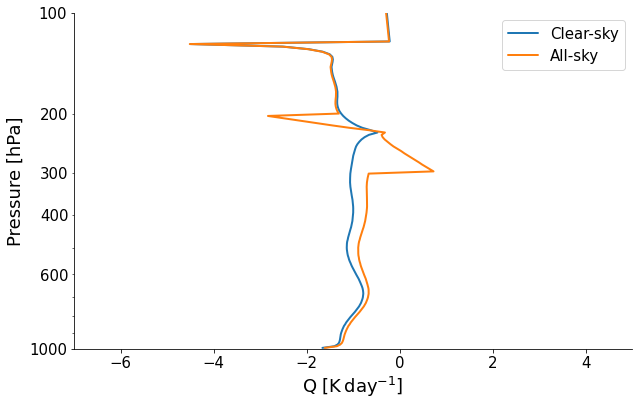

In [45]:
single_cloud = konrad.cloud.ConceptualCloud(
    atmosphere,  # required for consistent coordinates
    cloud_top=200e2,  # in Pa
    depth=100e2,  # in Pa
    phase="ice",  # "ice" or "liquid"
    water_path=24.0,  # in g/m^3
    cloud_fraction=0.3,  # [0-1]
)

rrtmg.update_heatingrates(
    atmosphere=atmosphere,
    cloud=single_cloud,
)

fig, ax = plt.subplots()
ty.plots.profile_p_log(rrtmg["plev"], rrtmg["net_htngrt_clr"][-1], label="Clear-sky")
ty.plots.profile_p_log(rrtmg["plev"], rrtmg["net_htngrt"][-1], label="All-sky")
ax.legend()
ax.set_ylim(1000e2, 100e2)
ax.set_xlim(-7, 5)
ax.set_xlabel("Q $\sf [K\,day^{-1}]$")